# Bike Demand Prediction — Experimentation Notebook

Starting fresh. This notebook will be rebuilt section by section.

## 1. Load raw data

UCI Bike Sharing dataset, hourly resolution. One row per station-system-hour
(the whole system is one series here, not per-station) with weather and
calendar context alongside the target, `cnt`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.width', 140)

In [2]:
df = pd.read_csv('../data/raw/hour.csv', parse_dates=['dteday'])
print(df.shape)
df.head()

(17379, 17)


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


## 2. EDA

In [3]:
# Null check
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nTotal missing values: {df.isnull().sum().sum()}")

Missing values per column:
instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

Total missing values: 0


In [4]:
df.describe()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2012-01-02 04:08:34.552045,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
min,1.0000,2011-01-01 00:00:00,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2011-07-04 00:00:00,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,2012-01-02 00:00:00,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,2012-07-02 00:00:00,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,2012-12-31 00:00:00,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000
std,5017.0295,NaN,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599


### Data quality and shape — summary

- **Zero missing values** across all 17,379 rows and 17 columns — no imputation needed anywhere.
- Row counts match expectations for an hourly series spanning 2011-2012 exactly, and every
  categorical column's value counts look sane (e.g. `holiday`=500 rows, `weathersit=4` only 3 rows
  — genuinely rare severe weather, not a data error, but too few rows to draw reliable conclusions
  from wherever it shows up later).
- Numeric predictors (`temp`, `atemp`, `hum`, `windspeed`) are all pre-normalized to [0, 1] in this
  dataset — no additional scaling needed for tree models, though linear/GLM candidates will still
  need it later since their coefficients and optimizers are scale-sensitive.

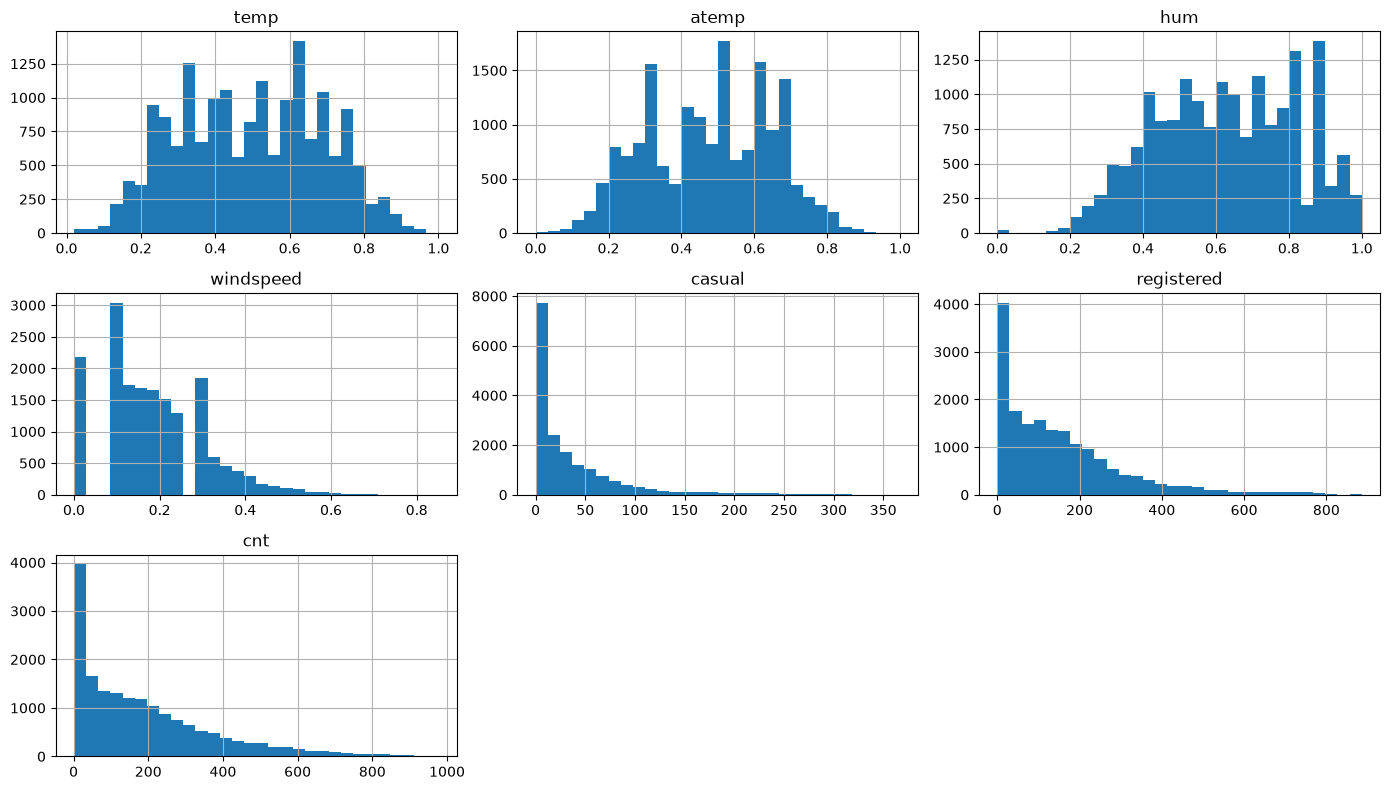

In [5]:
# Distribution of every numeric feature, not just the target -- worth checking before deciding how
# to encode anything (e.g. weathersit/season are categorical codes, not continuous, so their
# "distributions" here are really just category counts).
numeric_cols = ['temp', 'atemp', 'hum', 'windspeed', 'casual', 'registered', 'cnt']
df[numeric_cols].hist(bins=30, figsize=(14, 8))
plt.tight_layout()
plt.show()

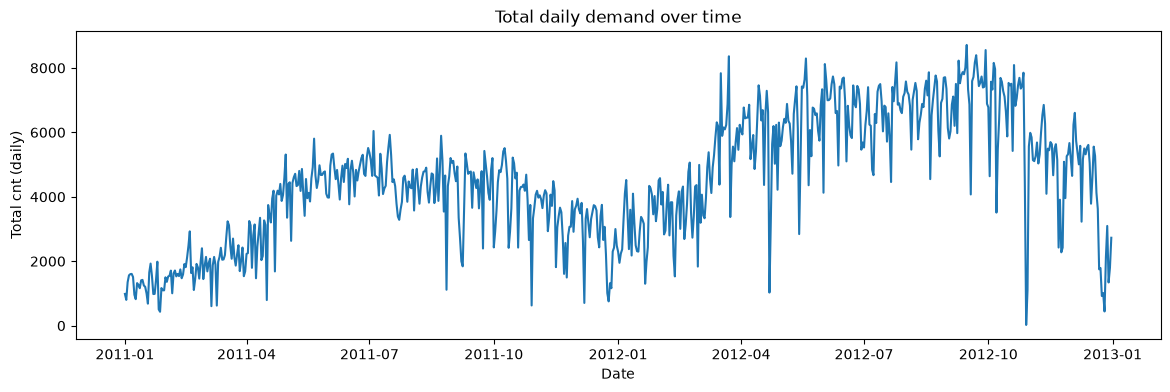

In [6]:
# 1. Daily total demand over time -- the full-resolution view of the series, aggregated up from
# hourly to daily so the trend/seasonality is visible without hourly noise drowning it out.
daily = df.groupby('dteday')['cnt'].sum()

plt.figure(figsize=(14, 4))
plt.plot(daily.index, daily.values)
plt.title('Total daily demand over time')
plt.xlabel('Date')
plt.ylabel('Total cnt (daily)')
plt.show()

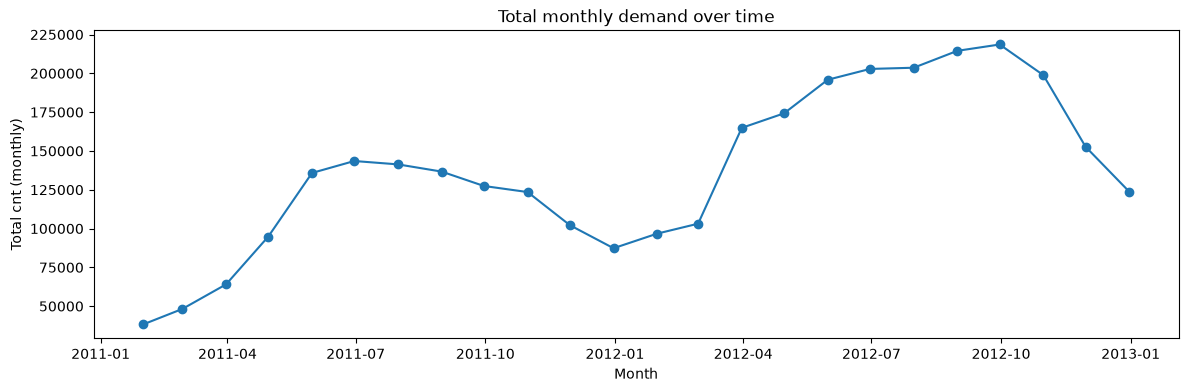

In [7]:
# 2. Monthly total demand -- smooths out day-to-day noise, makes the seasonal (summer-peak,
# winter-trough) pattern the dominant visible signal.
monthly = df.set_index('dteday').resample('ME')['cnt'].sum()

plt.figure(figsize=(14, 4))
plt.plot(monthly.index, monthly.values, marker='o')
plt.title('Total monthly demand over time')
plt.xlabel('Month')
plt.ylabel('Total cnt (monthly)')
plt.show()

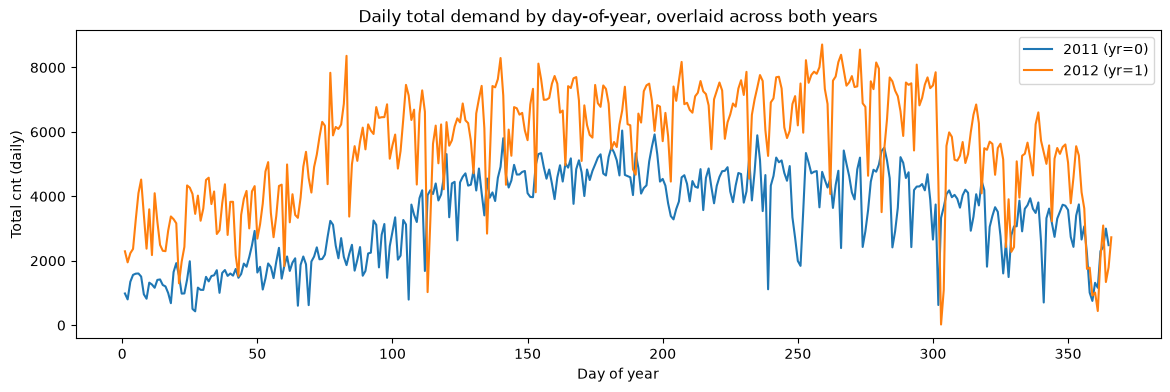

In [8]:
# 3. Year-over-year comparison -- overlay 2011 and 2012 by day-of-year, so seasonal shape and
# the year-over-year growth level are visible in the same view rather than two separate charts.
df['day_of_year'] = df['dteday'].dt.dayofyear
yearly_by_doy = df.groupby(['yr', 'day_of_year'])['cnt'].sum().unstack(level=0)

plt.figure(figsize=(14, 4))
plt.plot(yearly_by_doy.index, yearly_by_doy[0], label='2011 (yr=0)')
plt.plot(yearly_by_doy.index, yearly_by_doy[1], label='2012 (yr=1)')
plt.title('Daily total demand by day-of-year, overlaid across both years')
plt.xlabel('Day of year')
plt.ylabel('Total cnt (daily)')
plt.legend()
plt.show()

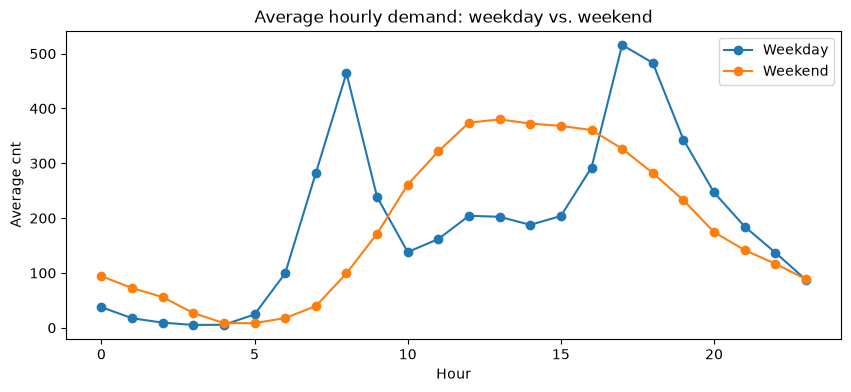

In [9]:
# 4. Weekday vs weekend -- average hourly demand shape, not totals, since the point here is the
# *shape* difference (commute bimodal vs. leisure single-hump), not which has more total volume.
df['is_weekend'] = df['weekday'].isin([0, 6])  # dataset convention: 0=Sunday, 6=Saturday
weekday_weekend_shape = df.groupby(['is_weekend', 'hr'])['cnt'].mean().unstack(level=0)
weekday_weekend_shape.columns = ['Weekday', 'Weekend']

plt.figure(figsize=(10, 4))
plt.plot(weekday_weekend_shape.index, weekday_weekend_shape['Weekday'], marker='o', label='Weekday')
plt.plot(weekday_weekend_shape.index, weekday_weekend_shape['Weekend'], marker='o', label='Weekend')
plt.title('Average hourly demand: weekday vs. weekend')
plt.xlabel('Hour')
plt.ylabel('Average cnt')
plt.legend()
plt.show()

### Time series views — what to look for and why

- **Daily total demand**: the noisiest of the four views, but the right one for spotting genuine
  anomalies at the day level — a single day that drops to near-zero (system shutdown) or spikes
  unnaturally stands out here, not in a monthly aggregate. Watch specifically for the Hurricane
  Sandy window (late Oct 2012) and any other days that look like a data issue rather than real
  demand.
- **Monthly total demand**: smooths out day-to-day noise so the seasonal shape is unmistakable —
  expect a clear summer peak and winter trough, since bike-share demand is fundamentally
  weather-driven. This is the view that justifies treating month/season as real signal rather than
  noise in feature engineering.
- **Year-over-year overlay (day-of-year)**: the 2012 line should sit visibly above the 2011 line
  for most of the year, at a similar seasonal shape — that's the system-growth pattern already
  quantified in the year-groupby table earlier, now visible as a trend rather than just two summary
  numbers. If the gap between the two lines widens or narrows over the course of the year rather
  than staying roughly constant, that's evidence growth wasn't uniform — worth remembering when
  recency-weighting decisions come up later.
- **Weekday vs. weekend hourly shape**: this is the chart that motivates almost every modeling
  decision downstream. Weekdays should show a sharp bimodal shape (two commute peaks, a trough
  midday); weekends should show a single broad midday/afternoon hump (leisure riding). That
  structural difference — not just a magnitude difference — is why `hr` needs to interact with
  day-type information rather than being treated as a single smooth function on its own.

**Net takeaway**: demand has real trend (year-over-year growth), real seasonality (month/season),
and a genuinely different *shape* of demand depending on day type — not just a different volume.
Any model that treats these as one smooth function of time will underfit; feature engineering
needs to give the model explicit access to all three (trend, seasonality, and day-type shape)
rather than relying on it to discover them from a single time index.

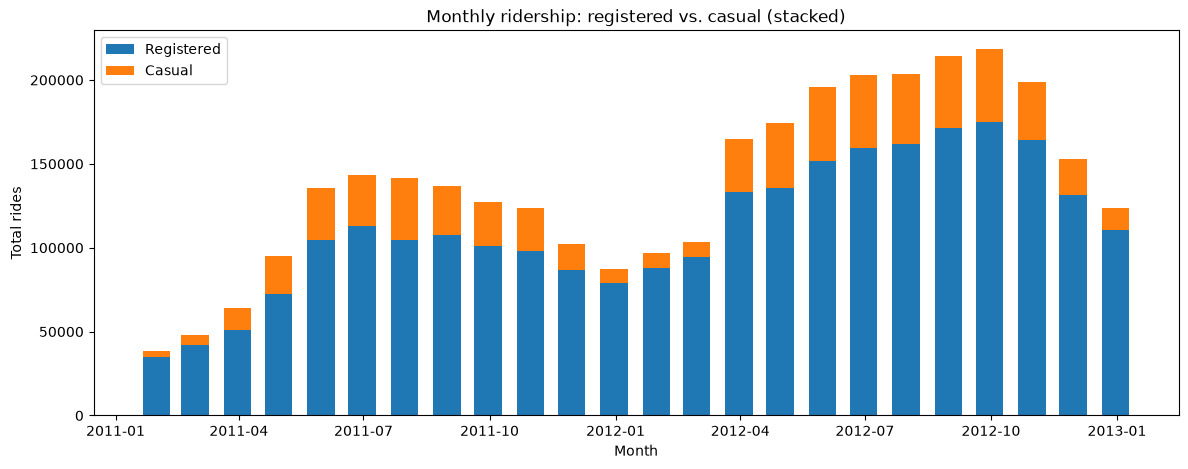

Overall share -- registered: 81.2%   casual: 18.8%


In [10]:
# Casual vs. registered split -- doesn't feed modeling directly (both are dropped as target
# components, per the leakage check earlier), but useful to see who's actually riding and when.
monthly_split = df.set_index('dteday').resample('ME')[['casual', 'registered']].sum()

plt.figure(figsize=(14, 5))
plt.bar(monthly_split.index, monthly_split['registered'], width=20, label='Registered')
plt.bar(monthly_split.index, monthly_split['casual'], width=20, bottom=monthly_split['registered'], label='Casual')
plt.title('Monthly ridership: registered vs. casual (stacked)')
plt.xlabel('Month')
plt.ylabel('Total rides')
plt.legend()
plt.show()

print(f"Overall share -- registered: {df['registered'].sum() / df['cnt'].sum():.1%}   "
      f"casual: {df['casual'].sum() / df['cnt'].sum():.1%}")

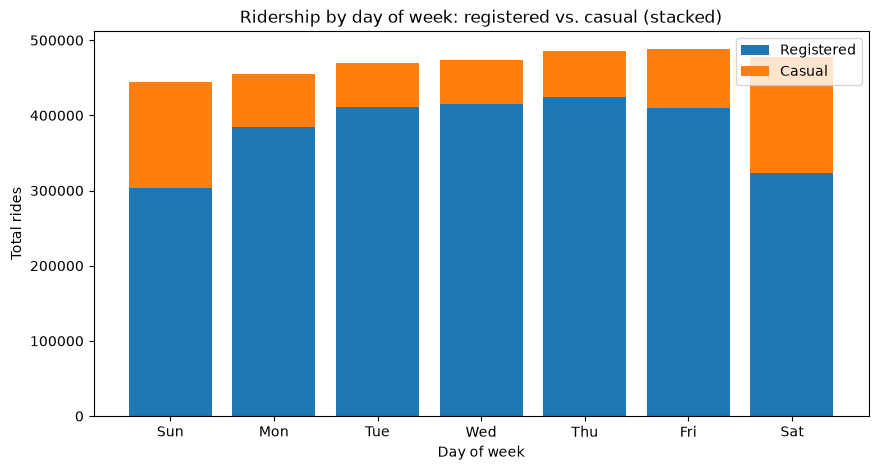

Casual share of ridership by day:
Sun    0.316
Mon    0.155
Tue    0.123
Wed    0.121
Thu    0.127
Fri    0.160
Sat    0.322
dtype: float64


In [11]:
# Same casual/registered split, this time by day of week -- tests directly whether casual riders
# lean more heavily toward weekends/leisure days than registered riders do.
weekday_split = df.groupby('weekday')[['casual', 'registered']].sum()
weekday_labels = ['Sun', 'Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat']  # dataset convention: 0=Sunday

plt.figure(figsize=(10, 5))
plt.bar(weekday_labels, weekday_split['registered'], label='Registered')
plt.bar(weekday_labels, weekday_split['casual'], bottom=weekday_split['registered'], label='Casual')
plt.title('Ridership by day of week: registered vs. casual (stacked)')
plt.xlabel('Day of week')
plt.ylabel('Total rides')
plt.legend()
plt.show()

casual_share_by_day = (weekday_split['casual'] / (weekday_split['casual'] + weekday_split['registered']))
print("Casual share of ridership by day:")
print(casual_share_by_day.set_axis(weekday_labels).round(3))

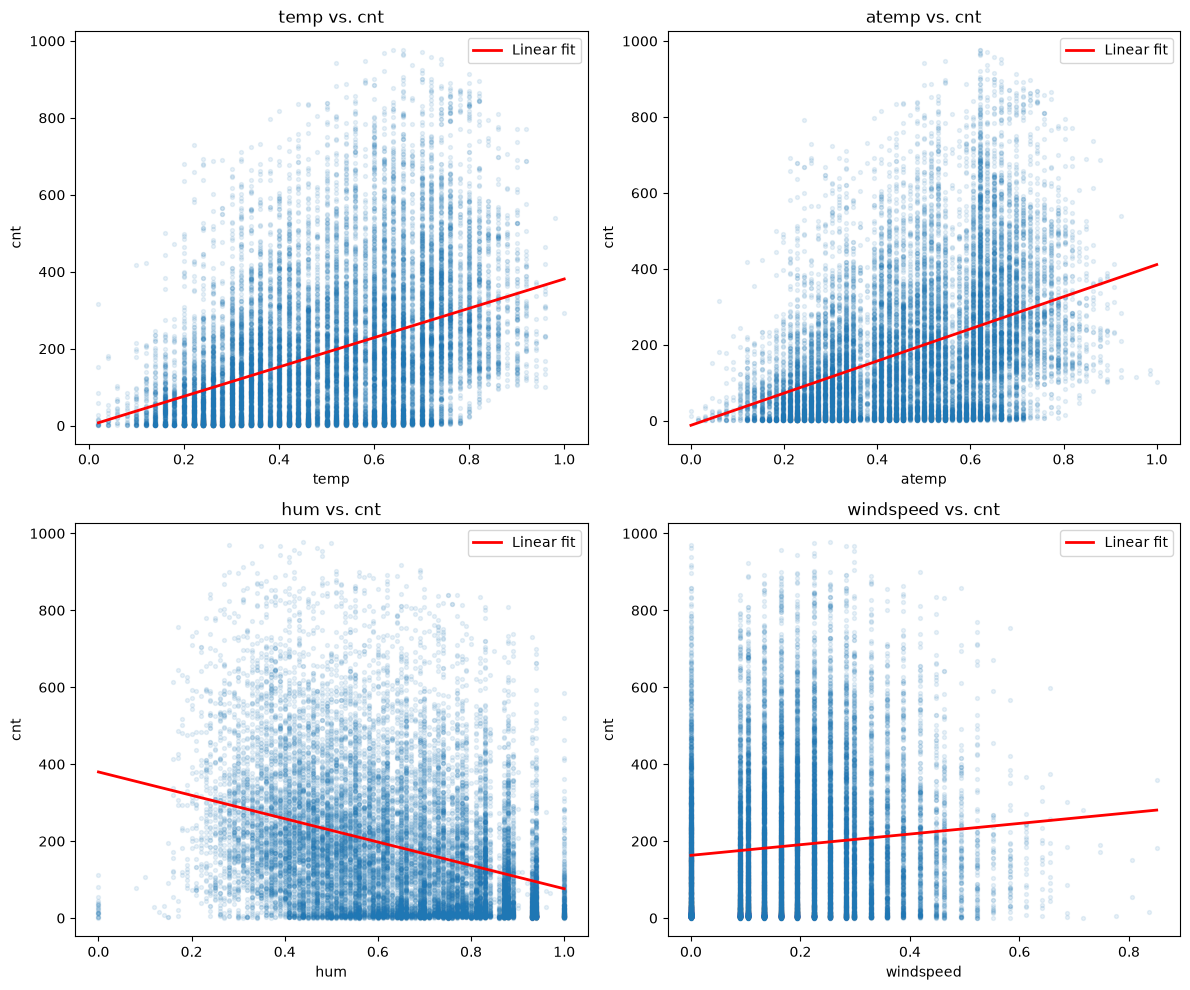

In [12]:
# Scatter plots of continuous predictors vs. cnt, each with a linear fit overlaid -- if the real
# relationship is linear, the points should hug that line; if it's not, the scatter shape will
# visibly curve away from it (this is the visual check that decides whether OLS is a reasonable
# starting assumption for a given feature, or whether it needs a transform/interaction).
continuous_cols = ['temp', 'atemp', 'hum', 'windspeed']

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for ax, col in zip(axes.flat, continuous_cols):
    ax.scatter(df[col], df['cnt'], alpha=0.1, s=8)
    z = np.polyfit(df[col], df['cnt'], 1)
    x_line = np.linspace(df[col].min(), df[col].max(), 100)
    ax.plot(x_line, np.poly1d(z)(x_line), color='red', linewidth=2, label='Linear fit')
    ax.set_title(f'{col} vs. cnt')
    ax.set_xlabel(col)
    ax.set_ylabel('cnt')
    ax.legend()
plt.tight_layout()
plt.show()

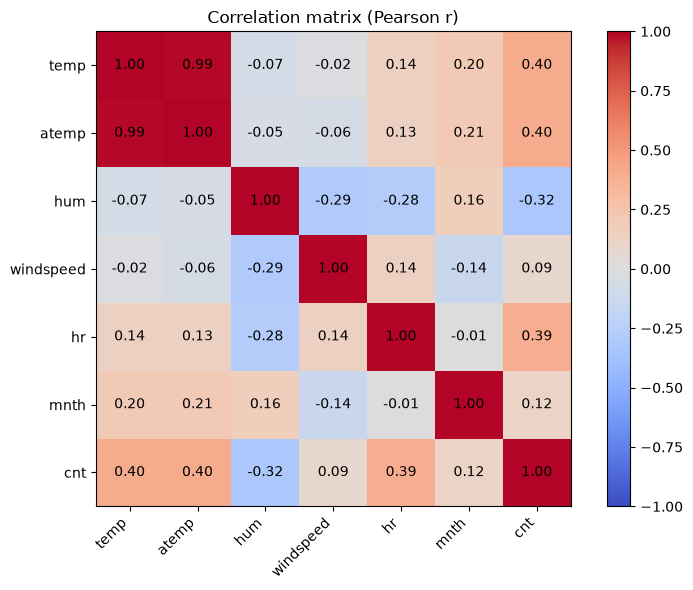

In [13]:
# Correlation heatmap -- a single number (Pearson r) per pair, quantifying LINEAR association only.
# Two variables can be perfectly related and still show r near 0 if the relationship is nonlinear
# (e.g. a U-shape) -- that's exactly why this needs to be read alongside the scatter plots above,
# not instead of them.
import matplotlib.pyplot as plt

corr_cols = ['temp', 'atemp', 'hum', 'windspeed', 'hr', 'mnth', 'cnt']
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_cols)))
ax.set_yticks(range(len(corr_cols)))
ax.set_xticklabels(corr_cols, rotation=45, ha='right')
ax.set_yticklabels(corr_cols)
for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        ax.text(j, i, f'{corr_matrix.iloc[i, j]:.2f}', ha='center', va='center', color='black')
plt.colorbar(im)
plt.title('Correlation matrix (Pearson r)')
plt.tight_layout()
plt.show()

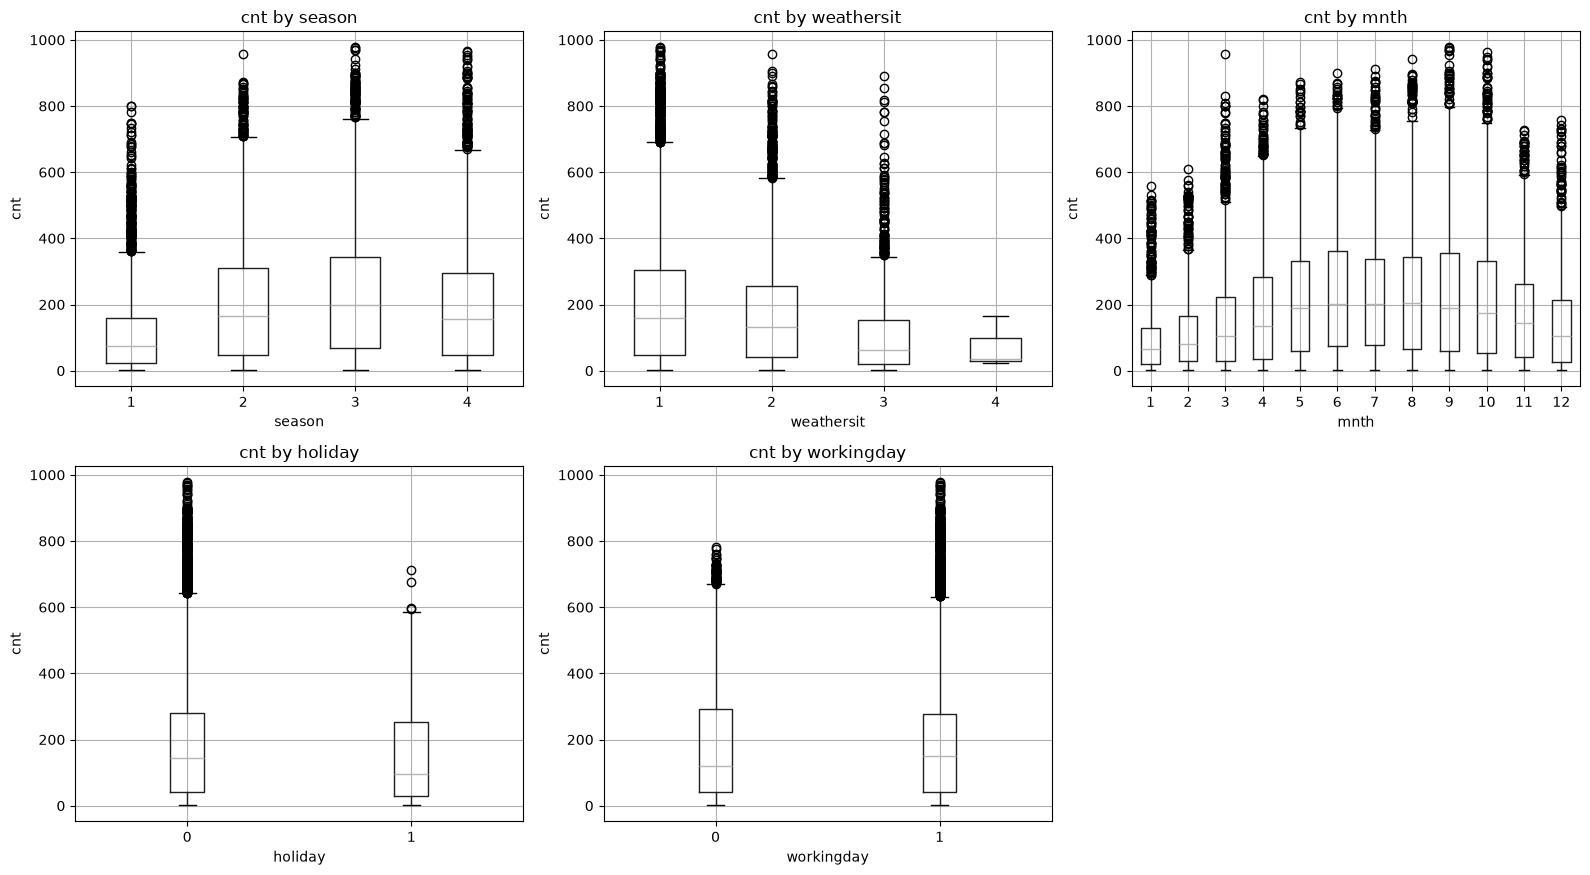

In [14]:
# Boxplots for categorical/discrete predictors vs. cnt -- shows the relationship's SHAPE for
# variables where "linear" doesn't really apply the same way (there's no meaningful slope for
# season 1 -> 2 -> 3 -> 4 the way there is for temp).
categorical_cols = ['season', 'weathersit', 'mnth', 'holiday', 'workingday']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, col in zip(axes.flat, categorical_cols):
    df.boxplot(column='cnt', by=col, ax=ax)
    ax.set_title(f'cnt by {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('cnt')
axes.flat[-1].set_visible(False)  # 5 plots in a 2x3 grid -- hide the unused 6th axis
plt.suptitle('')
plt.tight_layout()
plt.show()

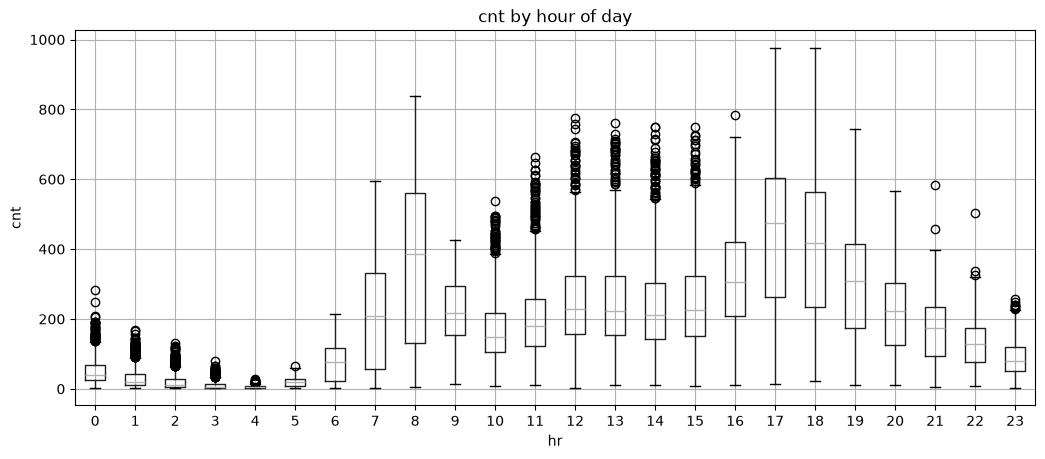

In [15]:
# hr gets its own plot -- 24 categories is too many for a clean boxplot grid slot, and it's the
# variable most likely to show a highly nonlinear (bimodal) shape rather than anything monotonic.
fig, ax = plt.subplots(figsize=(12, 5))
df.boxplot(column='cnt', by='hr', ax=ax)
ax.set_title('cnt by hour of day')
ax.set_xlabel('hr')
ax.set_ylabel('cnt')
plt.suptitle('')
plt.show()

### Linearity check — summary

Directly answering "are these relationships linear": mostly no.

- **`temp`/`atemp`**: the closest thing to linear here, but still shows real curvature — demand
  rises with temperature and appears to flatten (possibly dip) at the extreme high end, not a
  clean straight line.
- **`hum`**: a real negative relationship, but shaped more like a shrinking ceiling on maximum
  demand as humidity rises than a tight linear trend — a lot of the scatter at any given humidity
  level is unrelated to humidity itself.
- **`windspeed`**: essentially flat/noisy (r=0.09) — not a meaningful predictor on its own, linear
  or otherwise.
- **`hr`, `season`, `weathersit`, `mnth`**: not linear relationships at all — `hr` is sharply
  bimodal, the others are category-level shifts with no natural ordering. Pearson correlation
  (`hr` at r=0.39, similar magnitude to `temp`'s r=0.40) is actively misleading here — it can't
  distinguish a genuine near-linear trend from a strong-but-nonlinear one.

**Conclusion**: only `temp`/`atemp` and `hum` are even approximately linear. Everything else that matters is a shape or category effect. This is direct evidence
that a linear/GLM candidate will need real feature engineering (harmonics, one-hot encoding, a
quadratic temp term) to be competitive, while a tree-based model can use these features close to
as-is.

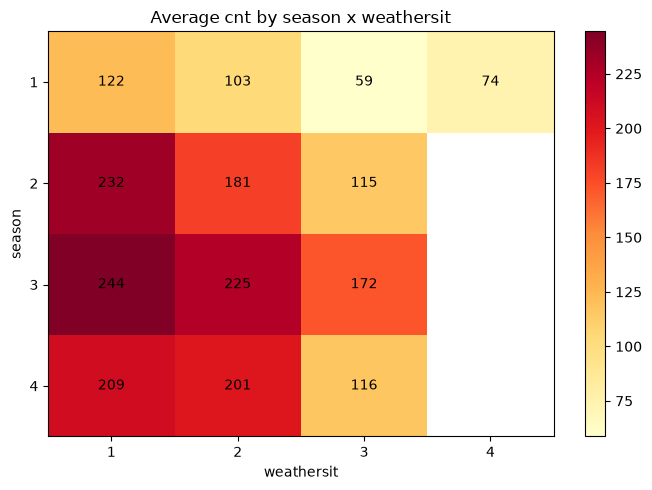

In [16]:
# Season x weathersit -- does bad weather hurt equally across seasons, or is winter+rain worse
# than summer+rain (e.g. cold rain vs. warm rain)?
season_weather_pivot = df.pivot_table(values='cnt', index='season', columns='weathersit', aggfunc='mean')

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(season_weather_pivot, cmap='YlOrRd', aspect='auto')
ax.set_xticks(range(len(season_weather_pivot.columns)))
ax.set_xticklabels(season_weather_pivot.columns)
ax.set_yticks(range(len(season_weather_pivot.index)))
ax.set_yticklabels(season_weather_pivot.index)
for i in range(len(season_weather_pivot.index)):
    for j in range(len(season_weather_pivot.columns)):
        val = season_weather_pivot.iloc[i, j]
        if pd.notna(val):
            ax.text(j, i, f'{val:.0f}', ha='center', va='center')
ax.set_xlabel('weathersit')
ax.set_ylabel('season')
ax.set_title('Average cnt by season x weathersit')
plt.colorbar(im)
plt.tight_layout()
plt.show()

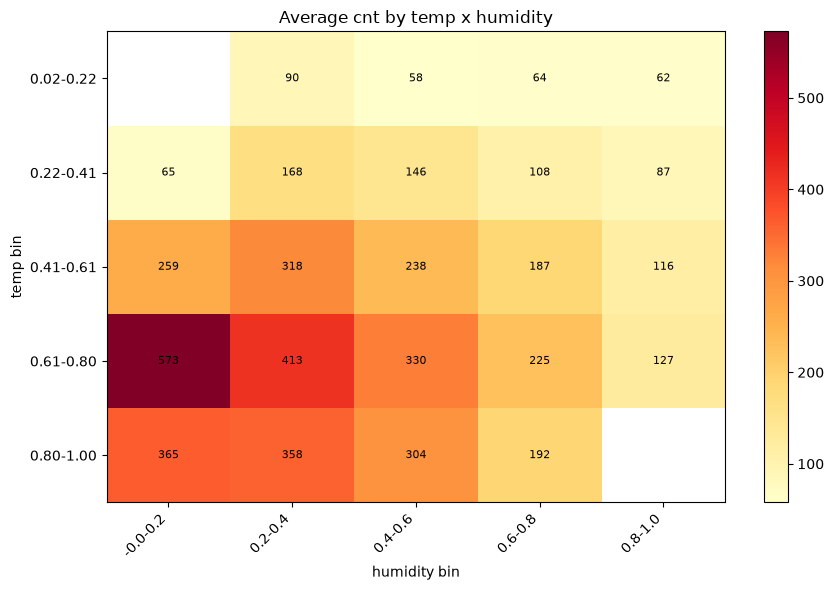

In [17]:
# temp x hum, binned -- the two weather variables most likely to interact (hot+humid feels very
# different from hot+dry; the raw scatter plots couldn't show this because they only look at one
# variable at a time).
df['temp_bin'] = pd.cut(df['temp'], bins=5)
df['hum_bin'] = pd.cut(df['hum'], bins=5)
temp_hum_pivot = df.pivot_table(values='cnt', index='temp_bin', columns='hum_bin', aggfunc='mean', observed=True)

fig, ax = plt.subplots(figsize=(9, 6))
im = ax.imshow(temp_hum_pivot, cmap='YlOrRd', aspect='auto')
ax.set_xticks(range(len(temp_hum_pivot.columns)))
ax.set_xticklabels([f'{iv.left:.1f}-{iv.right:.1f}' for iv in temp_hum_pivot.columns], rotation=45, ha='right')
ax.set_yticks(range(len(temp_hum_pivot.index)))
ax.set_yticklabels([f'{iv.left:.2f}-{iv.right:.2f}' for iv in temp_hum_pivot.index])
for i in range(len(temp_hum_pivot.index)):
    for j in range(len(temp_hum_pivot.columns)):
        val = temp_hum_pivot.iloc[i, j]
        if pd.notna(val):
            ax.text(j, i, f'{val:.0f}', ha='center', va='center', fontsize=8)
ax.set_xlabel('humidity bin')
ax.set_ylabel('temp bin')
ax.set_title('Average cnt by temp x humidity')
plt.colorbar(im)
plt.tight_layout()
plt.show()

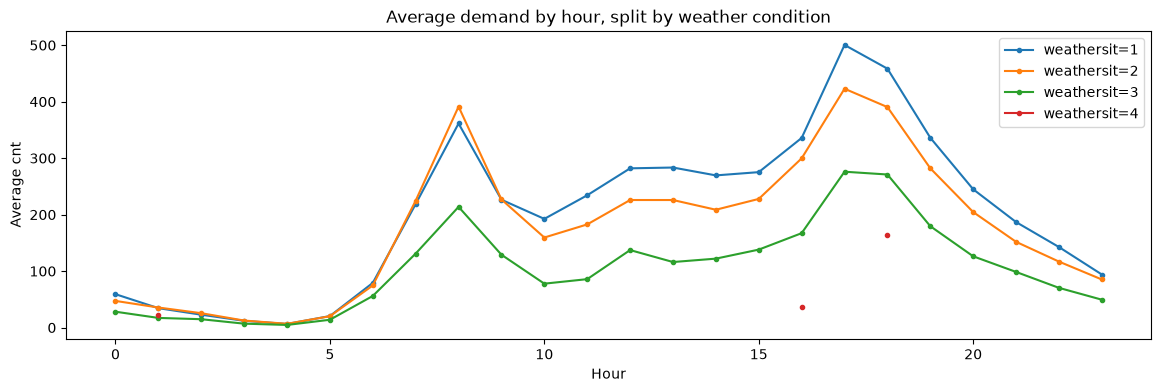

In [18]:
# weathersit x hour -- does bad weather suppress demand uniformly across the day, or does it hit
# commute hours less hard than leisure hours (commuters ride regardless; leisure riders don't)?
weather_hour_pivot = df.pivot_table(values='cnt', index='weathersit', columns='hr', aggfunc='mean')

fig, ax = plt.subplots(figsize=(14, 4))
for w in weather_hour_pivot.index:
    ax.plot(weather_hour_pivot.columns, weather_hour_pivot.loc[w], marker='o', markersize=3, label=f'weathersit={w}')
ax.set_xlabel('Hour')
ax.set_ylabel('Average cnt')
ax.set_title('Average demand by hour, split by weather condition')
ax.legend()
plt.show()

In [19]:
# windspeed x weathersit -- is windy+clear different from windy+rainy, or does weathersit dominate
# regardless of wind?
wind_weather_pivot = df.assign(wind_bin=pd.cut(df['windspeed'], bins=4)).pivot_table(
    values='cnt', index='wind_bin', columns='weathersit', aggfunc='mean', observed=True)
print(wind_weather_pivot.round(1))

weathersit              1      2      3     4
wind_bin                                     
(-0.000851, 0.213]  183.5  171.5  109.9  93.5
(0.213, 0.425]      238.6  179.9  115.1  36.0
(0.425, 0.638]      209.0  204.0   95.8   NaN
(0.638, 0.851]      159.5  150.3  142.3   NaN


### Weather interactions — summary

- **`season × weathersit`**: bad weather's cost isn't uniform — it hits winter (already the lowest
  base demand) proportionally harder than summer. A modulation effect, not a simple additive one.
- **`temp × hum`**: the strongest real interaction found in this EDA. Hot+dry is the single best
  condition for demand; humidity's drag on demand is much steeper at high temperatures than at low
  ones. A linear model needs an explicit `temp × hum` interaction term to represent this — separate
  `temp` and `hum` terms alone cannot.
- **`weathersit × hour`**: weather scales the existing bimodal commute curve down without
  reshaping it — a simpler kind of interaction than season×weathersit.
- **`windspeed × weathersit`**: no clean or reliable pattern; consistent with windspeed's
  near-zero standalone correlation. Not worth extra engineering effort.

**Modeling implication**: `temp × hum` is the one interaction worth explicitly engineering for
linear/GLM candidates later. Tree models get all of these interactions (and the season×weathersit
modulation) automatically through sequential splits, without needing them hand-specified — this is
part of why a GBM is favored over a linear model for this problem (see the model-choice discussion
above).

In [20]:
# Distribution and overdispersion check for casual and registered separately -- same tests run on
# cnt earlier, now applied to each component so we know what we're actually dealing with if they
# get modeled separately.
for col in ['casual', 'registered']:
    print(f"--- {col} ---")
    print(f"Mean:     {df[col].mean():.2f}")
    print(f"Variance: {df[col].var():.2f}")
    print(f"Variance / mean ratio: {df[col].var() / df[col].mean():.1f}  (>>1 => overdispersed)")
    print(f"Zero count: {(df[col] == 0).sum()}  ({(df[col] == 0).mean():.1%} of all rows)")
    print(f"Max: {df[col].max()}")
    print()

--- casual ---
Mean:     35.68
Variance: 2430.99
Variance / mean ratio: 68.1  (>>1 => overdispersed)
Zero count: 1581  (9.1% of all rows)
Max: 367

--- registered ---
Mean:     153.79
Variance: 22909.03
Variance / mean ratio: 149.0  (>>1 => overdispersed)
Zero count: 24  (0.1% of all rows)
Max: 886



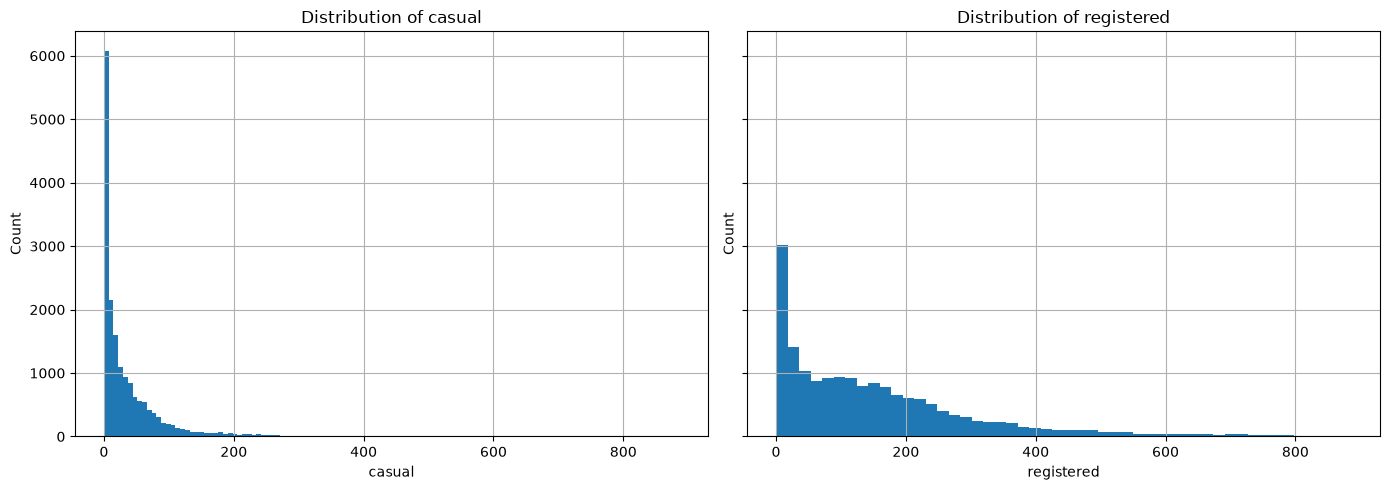

In [21]:
# Side-by-side distributions -- same x-axis range so the shape difference (not just the mean
# difference) is directly visible.
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True, sharey=True)
for ax, col in zip(axes, ['casual', 'registered']):
    df[col].hist(bins=50, ax=ax)
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

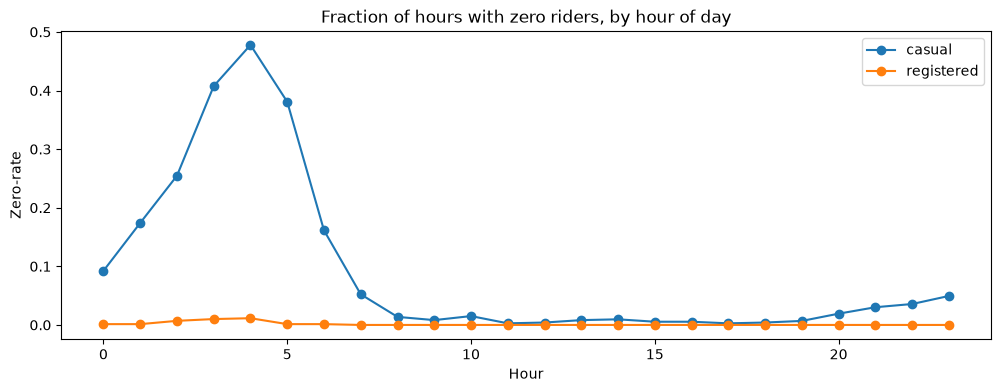

    casual_zero_rate  registered_zero_rate
hr                                        
0              0.092                 0.001
1              0.174                 0.001
2              0.255                 0.007
3              0.407                 0.010
4              0.478                 0.011
5              0.381                 0.001
6              0.161                 0.001
7              0.052                 0.000
8              0.014                 0.000
9              0.008                 0.000
10             0.015                 0.000
11             0.003                 0.000
12             0.004                 0.000
13             0.008                 0.000
14             0.010                 0.000
15             0.005                 0.000
16             0.005                 0.000
17             0.003                 0.000
18             0.004                 0.000
19             0.007                 0.000
20             0.019                 0.000
21         

In [22]:
# Zero-inflation by hour -- if casual's zeros are concentrated overnight (as expected) rather than
# spread evenly across the day, that's a meaningfully different pattern from registered, which
# should have very few zero-hours even overnight (commuters exist at all hours, just fewer).
zero_rate_by_hour = pd.DataFrame({
    'casual_zero_rate': df.groupby('hr')['casual'].apply(lambda s: (s == 0).mean()),
    'registered_zero_rate': df.groupby('hr')['registered'].apply(lambda s: (s == 0).mean()),
})

plt.figure(figsize=(12, 4))
plt.plot(zero_rate_by_hour.index, zero_rate_by_hour['casual_zero_rate'], marker='o', label='casual')
plt.plot(zero_rate_by_hour.index, zero_rate_by_hour['registered_zero_rate'], marker='o', label='registered')
plt.title('Fraction of hours with zero riders, by hour of day')
plt.xlabel('Hour')
plt.ylabel('Zero-rate')
plt.legend()
plt.show()

print(zero_rate_by_hour.round(3))

## 3. Feature Engineering

In [23]:
## 3. Chronological train / validation / test split

TEST_START = pd.Timestamp('2012-11-01')
TEST_END = pd.Timestamp('2012-12-31')  # inclusive

test_df_raw = df[(df['dteday'] >= TEST_START) & (df['dteday'] <= TEST_END)].copy()
dev_df_raw = df[df['dteday'] < TEST_START].copy()

print(f"Dev set:  {dev_df_raw['dteday'].min().date()} -> {dev_df_raw['dteday'].max().date()}  ({len(dev_df_raw)} rows)")
print(f"Test set: {test_df_raw['dteday'].min().date()} -> {test_df_raw['dteday'].max().date()}  ({len(test_df_raw)} rows)")

Dev set:  2011-01-01 -> 2012-10-31  (15919 rows)
Test set: 2012-11-01 -> 2012-12-31  (1460 rows)


In [24]:
# Expanding-window walk-forward folds -- date-based, explicit, reproducible.
fold_boundaries = [
    # (train_end_exclusive, val_start, val_end_inclusive)
    (pd.Timestamp('2012-05-01'), pd.Timestamp('2012-05-01'), pd.Timestamp('2012-06-30')),
    (pd.Timestamp('2012-07-01'), pd.Timestamp('2012-07-01'), pd.Timestamp('2012-08-31')),
    (pd.Timestamp('2012-09-01'), pd.Timestamp('2012-09-01'), pd.Timestamp('2012-10-31')),
]

def get_fold(data, train_end_exclusive, val_start, val_end_inclusive):
    train_fold = data[data['dteday'] < train_end_exclusive]
    val_fold = data[(data['dteday'] >= val_start) & (data['dteday'] <= val_end_inclusive)]
    return train_fold, val_fold

for i, (train_end, val_start, val_end) in enumerate(fold_boundaries, start=1):
    train_fold, val_fold = get_fold(dev_df_raw, train_end, val_start, val_end)
    print(f"Fold {i}: train up to {train_fold['dteday'].max().date()} ({len(train_fold)} rows)  |  "
          f"val {val_fold['dteday'].min().date()} -> {val_fold['dteday'].max().date()} ({len(val_fold)} rows)")

Fold 1: train up to 2012-04-30 (11539 rows)  |  val 2012-05-01 -> 2012-06-30 (1464 rows)
Fold 2: train up to 2012-06-30 (13003 rows)  |  val 2012-07-01 -> 2012-08-31 (1488 rows)
Fold 3: train up to 2012-08-31 (14491 rows)  |  val 2012-09-01 -> 2012-10-31 (1428 rows)


In [25]:
# Trend feature -- continuous, monotonically increasing, independent of season or recent noise.
# Built from actual elapsed days rather than reusing `instant` directly, so it stays correct even
# if row order or indexing ever changes upstream.
df = df.sort_values('dteday').reset_index(drop=True)
df['days_since_start'] = (df['dteday'] - df['dteday'].min()).dt.days

print(f"days_since_start range: {df['days_since_start'].min()} -> {df['days_since_start'].max()}")
df[['dteday', 'days_since_start']].drop_duplicates('dteday').head()

days_since_start range: 0 -> 730


,dteday,days_since_start
0,2011-01-01,0
24,2011-01-02,1
47,2011-01-03,2
69,2011-01-04,3
92,2011-01-05,4


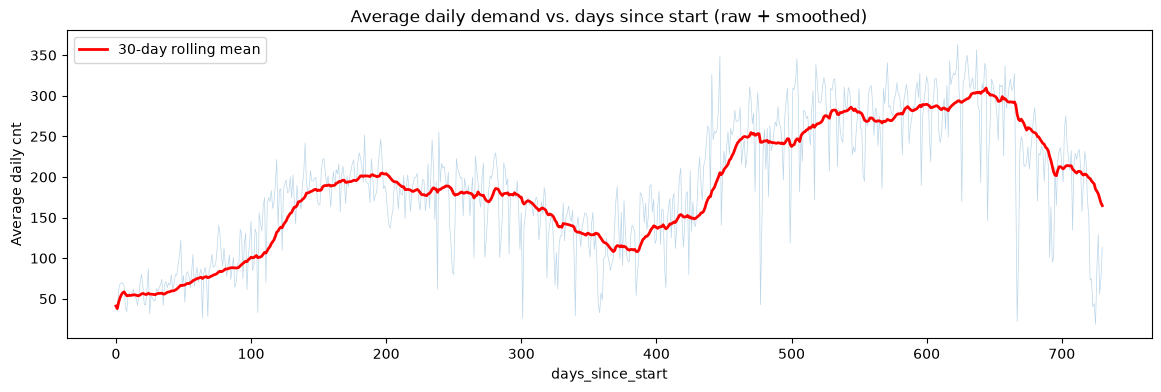

In [26]:
# Sanity check -- confirms this is actually capturing the growth trend, not just an arbitrary
# index. Should show a clear upward relationship with average demand.
trend_check = df.groupby('days_since_start')['cnt'].mean()

plt.figure(figsize=(14, 4))
plt.plot(trend_check.index, trend_check.values, alpha=0.3, linewidth=0.5)
plt.plot(trend_check.index, trend_check.rolling(30, min_periods=1).mean(), color='red', linewidth=2, label='30-day rolling mean')
plt.title('Average daily demand vs. days since start (raw + smoothed)')
plt.xlabel('days_since_start')
plt.ylabel('Average daily cnt')
plt.legend()
plt.show()

### Lag/rolling demand features and rush-hour flag

In [27]:
# Build a proper hourly timestamp once -- everything below keys off actual elapsed time, not row
# position, so the missing Hurricane Sandy day (a real gap in the hourly sequence) can't silently
# misalign a lag or rolling window.
df = df.sort_values('dteday').reset_index(drop=True)
df['timestamp'] = df['dteday'] + pd.to_timedelta(df['hr'], unit='h')


def build_lag_rolling_features(data, target_col, trail_avg_window_weeks=8):
    """Leakage-safe lag/rolling features for a single target column ('cnt', 'casual', or
    'registered'). Returns a copy of `data` with the new columns added, prefixed by target_col so
    e.g. calling this for 'casual' and 'registered' separately never collides on column names.

    Two different techniques are used deliberately:
    - Exact lags (t-24h, t-168h): merged on the actual timestamp offset by a fixed time delta, not
      shifted by row position. A plain `.shift(24)` would be silently wrong for every row after the
      missing Sandy day, since a 24-*row* shift no longer equals a 24-*hour* shift past that gap.
    - Rolling averages (prior 24h, prior 7d): computed with a time-based window (`'24h'`, `'7D'`)
      on a datetime index with `closed='left'`, which excludes the current row and correctly
      respects real elapsed time even across the gap -- unlike a fixed-row-count `.rolling(24)`.
    """
    data = data.sort_values('timestamp').reset_index(drop=True)

    # --- Exact lags, via timestamp merge (not row shift) ---
    lookup = data[['timestamp', target_col]].copy()
    for lag_hours, name in [(24, '24h'), (168, '168h')]:
        shifted = lookup.copy()
        shifted['timestamp'] = shifted['timestamp'] + pd.Timedelta(hours=lag_hours)
        shifted = shifted.rename(columns={target_col: f'{target_col}_lag_{name}'})
        data = data.merge(shifted, on='timestamp', how='left')

    # --- Rolling averages, time-based window, current row excluded ---
    ts_indexed = data.set_index('timestamp')[target_col]
    data[f'{target_col}_avg_prev_24h'] = ts_indexed.rolling('24h', closed='left').mean().values
    data[f'{target_col}_avg_prev_7d'] = ts_indexed.rolling('7D', closed='left').mean().values

    # --- Same weekday+hour trailing average (occurrence-based, not calendar-based -- naturally
    # self-corrects if a specific date is missing, since it counts valid past occurrences rather
    # than assuming a fixed number of calendar weeks). ---
    trail_col = f'{target_col}_trail_avg_hr_wd_{trail_avg_window_weeks}w'
    data[trail_col] = (
        data.groupby(['weekday', 'hr'])[target_col]
            .transform(lambda s: s.shift(1).rolling(window=trail_avg_window_weeks, min_periods=1).mean())
    )

    return data

In [28]:
# Example: build the full feature set for cnt (the default target). Calling this again with
# target_col='casual' or 'registered' later (if separate models get tested) reuses the exact same
# leakage-safe logic without rewriting it.
df = build_lag_rolling_features(df, target_col='cnt')

new_cols = [c for c in df.columns if c.startswith('cnt_lag_') or c.startswith('cnt_avg_') or c.startswith('cnt_trail_')]
print(f"New columns: {new_cols}")
print(f"Rows with any missing lag/rolling value: {df[new_cols].isna().any(axis=1).sum()} out of {len(df)}")
df[['timestamp'] + new_cols].head(10)

New columns: ['cnt_lag_24h', 'cnt_lag_168h', 'cnt_avg_prev_24h', 'cnt_avg_prev_7d', 'cnt_trail_avg_hr_wd_8w']
Rows with any missing lag/rolling value: 429 out of 17379


,timestamp,cnt_lag_24h,cnt_lag_168h,cnt_avg_prev_24h,cnt_avg_prev_7d,cnt_trail_avg_hr_wd_8w
0,2011-01-01 00:00:00,NaN,NaN,NaN,NaN,NaN
1,2011-01-01 01:00:00,NaN,NaN,16.000000,16.000000,NaN
2,2011-01-01 02:00:00,NaN,NaN,28.000000,28.000000,NaN
3,2011-01-01 03:00:00,NaN,NaN,29.333333,29.333333,NaN
4,2011-01-01 04:00:00,NaN,NaN,25.250000,25.250000,NaN
5,2011-01-01 05:00:00,NaN,NaN,20.400000,20.400000,NaN
6,2011-01-01 06:00:00,NaN,NaN,17.166667,17.166667,NaN
7,2011-01-01 07:00:00,NaN,NaN,15.000000,15.000000,NaN
8,2011-01-01 08:00:00,NaN,NaN,13.500000,13.500000,NaN
9,2011-01-01 09:00:00,NaN,NaN,12.888889,12.888889,NaN


In [29]:
# Rush-hour indicator -- explicit flag for the two commute peaks on workingdays, tested as an
# ablation later (with vs. without) rather than assumed to help, since LightGBM can likely already
# isolate this combination from hr + workingday on its own.
MORNING_RUSH = (7, 9)   # inclusive
EVENING_RUSH = (17, 19)  # inclusive

df['is_rush_hour'] = (
    df['workingday'].eq(1) &
    (df['hr'].between(*MORNING_RUSH) | df['hr'].between(*EVENING_RUSH))
).astype(int)

print(f"Rush-hour rows: {df['is_rush_hour'].sum()} ({df['is_rush_hour'].mean():.1%} of all rows)")
print(df.groupby('is_rush_hour')['cnt'].agg(['mean', 'median', 'count']))

Rush-hour rows: 2983 (17.2% of all rows)
                    mean  median  count
is_rush_hour                           
0             146.665324   108.0  14396
1             396.005699   366.0   2983


### Correlation check among engineered features

Run before finalizing the feature list, since its result (two highly correlated pairs) is what
determines whether `cnt_lag_168h` gets dropped below.

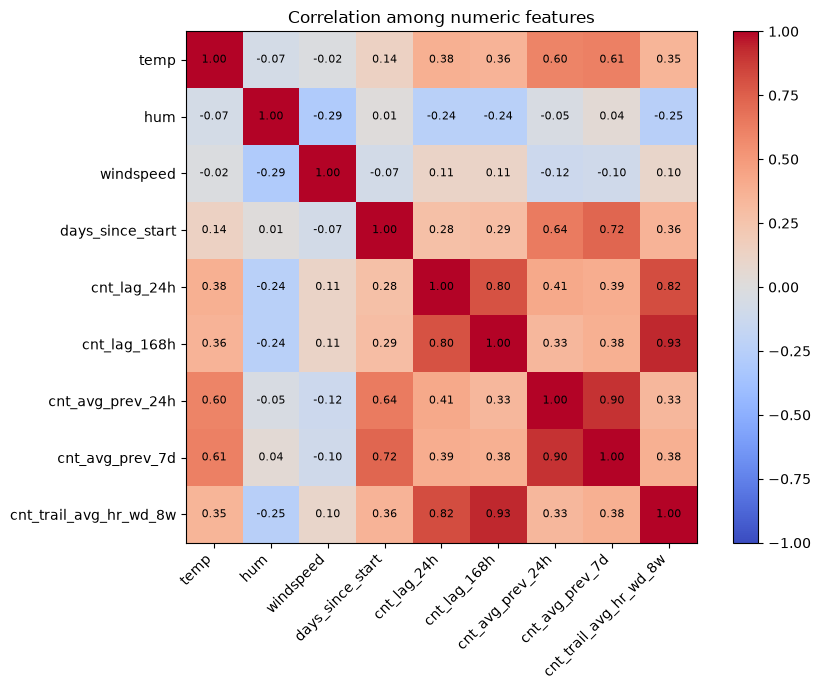

In [30]:
# Correlation among engineered features -- not to decide splits for the tree, but to know ahead of
# time whether feature importance will be diluted/unstable across near-duplicate features, and to
# catch anything so redundant it's not worth keeping at all.
numeric_feature_cols = ['temp', 'hum', 'windspeed', 'days_since_start',
                         'cnt_lag_24h', 'cnt_lag_168h', 'cnt_avg_prev_24h', 'cnt_avg_prev_7d',
                         'cnt_trail_avg_hr_wd_8w']

corr_matrix = df[numeric_feature_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(numeric_feature_cols)))
ax.set_yticks(range(len(numeric_feature_cols)))
ax.set_xticklabels(numeric_feature_cols, rotation=45, ha='right')
ax.set_yticklabels(numeric_feature_cols)
for i in range(len(numeric_feature_cols)):
    for j in range(len(numeric_feature_cols)):
        ax.text(j, i, f'{corr_matrix.iloc[i, j]:.2f}', ha='center', va='center', fontsize=8)
plt.colorbar(im)
plt.title('Correlation among numeric features')
plt.tight_layout()
plt.show()

In [31]:
# Flag any pair above a threshold explicitly, rather than eyeballing the heatmap for 9x9=36 cells.
threshold = 0.85
high_corr_pairs = []
for i in range(len(numeric_feature_cols)):
    for j in range(i + 1, len(numeric_feature_cols)):
        r = corr_matrix.iloc[i, j]
        if abs(r) >= threshold:
            high_corr_pairs.append((numeric_feature_cols[i], numeric_feature_cols[j], r))

print(f"Feature pairs with |r| >= {threshold}:")
for f1, f2, r in sorted(high_corr_pairs, key=lambda x: -abs(x[2])):
    print(f"  {f1:25s} <-> {f2:25s}  r={r:.3f}")
if not high_corr_pairs:
    print("  (none)")

Feature pairs with |r| >= 0.85:
  cnt_lag_168h              <-> cnt_trail_avg_hr_wd_8w     r=0.933
  cnt_avg_prev_24h          <-> cnt_avg_prev_7d            r=0.905


### Final feature set

`cnt_lag_168h` dropped -- r=0.93 with `cnt_trail_avg_hr_wd_8w` (see correlation check above), and
the smoothed 8-week trailing average is the more deliberately-designed, already-validated feature
of the two. `cnt_avg_prev_24h`/`cnt_avg_prev_7d` (r=0.90) are both kept -- different time horizons
that are informative even when correlated (the *gap* between them signals a level shift), unlike
the near-duplicate lag/trailing-average pair.

In [32]:
FEATURE_COLS = [
    'hr', 'weekday', 'mnth', 'season', 'holiday', 'workingday', 'weathersit',
    'temp', 'hum', 'windspeed',
    'days_since_start',
    'cnt_lag_24h', 'cnt_avg_prev_24h', 'cnt_avg_prev_7d', 'cnt_trail_avg_hr_wd_8w',
    'is_rush_hour',
]
print(f"Total features: {len(FEATURE_COLS)}")

Total features: 16


In [33]:
# Leakage/null audit -- every lag/rolling feature has its own cold-start requirement (the 168h lag
# needs a full week of prior history, the longest of the bunch), so this drops more rows than the
# single trailing-average version did earlier. Confirming the count and where those rows sit is
# worth doing explicitly rather than silently dropping and moving on.
missing_by_feature = df[FEATURE_COLS].isna().sum()
print("Missing values per feature:")
print(missing_by_feature[missing_by_feature > 0])

rows_with_any_missing = df[FEATURE_COLS].isna().any(axis=1)
print(f"\nRows with at least one missing feature: {rows_with_any_missing.sum()} out of {len(df)}")
print(f"Date range of affected rows: {df.loc[rows_with_any_missing, 'dteday'].min().date()} "
      f"-> {df.loc[rows_with_any_missing, 'dteday'].max().date()}")

Missing values per feature:
cnt_lag_24h               160
cnt_avg_prev_24h            2
cnt_avg_prev_7d             1
cnt_trail_avg_hr_wd_8w    168
dtype: int64

Rows with at least one missing feature: 301 out of 17379
Date range of affected rows: 2011-01-01 -> 2012-12-26


In [34]:
# Drop cold-start rows -- no global-mean fallback, consistent with the leakage-safety rule
# established in the original feature engineering section.
before = len(df)
df_model = df.dropna(subset=FEATURE_COLS).reset_index(drop=True)
print(f"Dropped {before - len(df_model)} row(s) with incomplete lag/rolling history.")
print(f"Remaining rows: {len(df_model)}")

Dropped 301 row(s) with incomplete lag/rolling history.
Remaining rows: 17078


## 4. Model Tracking setup

In [35]:
import mlflow
mlflow.set_experiment("bike_demand_prediction_v3")
print(mlflow.get_experiment_by_name("bike_demand_prediction_v3"))

/opt/anaconda3/envs/bikeproject/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<Experiment: artifact_location=('/Users/varshithtipirneni/Desktop/Cowork Homebase/02 Projects/Bike Demand '
 'Prediction/notebooks/mlruns/2'), creation_time=1789334784250, effective_trace_archival_retention=None, experiment_id='2', last_update_time=1789334784250, lifecycle_stage='active', name='bike_demand_prediction_v3', tags={}, trace_location=None, workspace='default'>


## 5. Baseline — naive seasonal model

In [36]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

In [39]:
def evaluate_naive_seasonal(data, fold_boundaries):
    fold_metrics = []

    with mlflow.start_run(run_name="naive_seasonal_baseline"):
        mlflow.log_param("method", "cnt_lag_168h (same weekday+hour, 1 week prior)")
        mlflow.log_param("n_folds", len(fold_boundaries))

        for fold_idx, (train_end, val_start, val_end) in enumerate(fold_boundaries):
            val_fold = data[(data['timestamp'] >= val_start) & (data['timestamp'] <= val_end)]
            val_fold = val_fold.dropna(subset=['cnt_lag_168h'])

            y_val = val_fold['cnt'].values
            preds = val_fold['cnt_lag_168h'].values

            fold_mae = mean_absolute_error(y_val, preds)
            fold_rmse = np.sqrt(mean_squared_error(y_val, preds))
            fold_mape = mean_absolute_percentage_error(y_val, preds)*100

            fold_metrics.append({"mae": fold_mae, "rmse": fold_rmse, "mape": fold_mape})

            mlflow.log_metrics({
                f"fold_{fold_idx}_mae": fold_mae,
                f"fold_{fold_idx}_rmse": fold_rmse,
                f"fold_{fold_idx}_mape": fold_mape,
            })

            print(f"Fold {fold_idx}: val={len(val_fold)} "
                  f"| MAE={fold_mae:.1f} RMSE={fold_rmse:.1f} MAPE={fold_mape:.1f}%")

        val_mae_mean = np.mean([m["mae"] for m in fold_metrics])
        val_mae_std = np.std([m["mae"] for m in fold_metrics])
        val_rmse_mean = np.mean([m["rmse"] for m in fold_metrics])
        val_rmse_std = np.std([m["rmse"] for m in fold_metrics])
        val_mape_mean = np.mean([m["mape"] for m in fold_metrics])
        val_mape_std = np.std([m["mape"] for m in fold_metrics])

        mlflow.log_metrics({
            "val_mae_mean": val_mae_mean, "val_mae_std": val_mae_std,
            "val_rmse_mean": val_rmse_mean, "val_rmse_std": val_rmse_std,
            "val_mape_mean": val_mape_mean, "val_mape_std": val_mape_std,
        })

        print(f"\nVal summary -- MAE: {val_mae_mean:.1f} (+/-{val_mae_std:.1f}) "
              f"| RMSE: {val_rmse_mean:.1f} (+/-{val_rmse_std:.1f}) "
              f"| MAPE: {val_mape_mean:.1f}% (+/-{val_mape_std:.1f}%)")

    return fold_metrics

fold_metrics_naive = evaluate_naive_seasonal(df, fold_boundaries)

Fold 0: val=1441 | MAE=57.1 RMSE=99.1 MAPE=35.4%
Fold 1: val=1465 | MAE=53.4 RMSE=90.6 MAPE=30.2%
Fold 2: val=1405 | MAE=64.0 RMSE=114.0 MAPE=37.4%

Val summary -- MAE: 58.1 (+/-4.4) | RMSE: 101.2 (+/-9.7) | MAPE: 34.3% (+/-3.0%)


## 6. Light GBM - Target='cnt'

In [41]:
CATEGORICAL_FEATURES = ['season', 'weathersit', 'weekday', 'mnth', 'hr']

In [42]:
import lightgbm as lgb

LGB_PARAMS = dict(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=32,
    random_state=42,
)

def run_walk_forward(data, target_col, feature_cols, categorical_features, run_name):
    fold_metrics = []

    with mlflow.start_run(run_name=run_name):
        mlflow.log_params(LGB_PARAMS)
        mlflow.log_param("feature_cols", feature_cols)
        mlflow.log_param("categorical_features", categorical_features)
        mlflow.log_param("target_col", target_col)
        mlflow.log_param("n_folds", len(fold_boundaries))

        for fold_idx, (train_end, val_start, val_end) in enumerate(fold_boundaries):
            train_fold = data[data['timestamp'] < train_end]
            val_fold = data[(data['timestamp'] >= val_start) & (data['timestamp'] <= val_end)]

            X_train, y_train = train_fold[feature_cols], train_fold[target_col]
            X_val, y_val = val_fold[feature_cols], val_fold[target_col]

            model = lgb.LGBMRegressor(**LGB_PARAMS)
            model.fit(
                X_train, y_train,
                categorical_feature=categorical_features,
            )

            preds = model.predict(X_val)
            preds = np.clip(preds, 0, None)  # cnt can't be negative

            fold_mae = mean_absolute_error(y_val, preds)
            fold_rmse = np.sqrt(mean_squared_error(y_val, preds))
            fold_mape = mean_absolute_percentage_error(y_val, preds) * 100

            fold_metrics.append({"mae": fold_mae, "rmse": fold_rmse, "mape": fold_mape})

            mlflow.log_metrics({
                f"fold_{fold_idx}_mae": fold_mae,
                f"fold_{fold_idx}_rmse": fold_rmse,
                f"fold_{fold_idx}_mape": fold_mape,
            })

            print(f"Fold {fold_idx}: train={len(train_fold)} val={len(val_fold)} "
                  f"| MAE={fold_mae:.1f} RMSE={fold_rmse:.1f} MAPE={fold_mape:.1f}%")

        val_mae_mean = np.mean([m["mae"] for m in fold_metrics])
        val_mae_std = np.std([m["mae"] for m in fold_metrics])
        val_rmse_mean = np.mean([m["rmse"] for m in fold_metrics])
        val_rmse_std = np.std([m["rmse"] for m in fold_metrics])
        val_mape_mean = np.mean([m["mape"] for m in fold_metrics])
        val_mape_std = np.std([m["mape"] for m in fold_metrics])

        mlflow.log_metrics({
            "val_mae_mean": val_mae_mean, "val_mae_std": val_mae_std,
            "val_rmse_mean": val_rmse_mean, "val_rmse_std": val_rmse_std,
            "val_mape_mean": val_mape_mean, "val_mape_std": val_mape_std,
        })

        print(f"\nVal summary -- MAE: {val_mae_mean:.1f} (+/-{val_mae_std:.1f}) "
              f"| RMSE: {val_rmse_mean:.1f} (+/-{val_rmse_std:.1f}) "
              f"| MAPE: {val_mape_mean:.1f}% (+/-{val_mape_std:.1f}%)")

    return fold_metrics

fold_metrics_cnt = run_walk_forward(
    df_model, target_col='cnt', feature_cols=FEATURE_COLS,
    categorical_features=CATEGORICAL_FEATURES, run_name="cnt_direct_baseline",
)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000239 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1494
[LightGBM] [Info] Number of data points in the train set: 11266, number of used features: 16
[LightGBM] [Info] Start training from score 157.059382
Fold 0: train=11266 val=1441 | MAE=41.8 RMSE=63.2 MAPE=28.1%
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000204 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1496
[LightGBM] [Info] Number of data points in the train set: 12730, number of used features: 16
[LightGBM] [Info] Start training from score 170.316261
Fold 1: train=12730 val=1465 | MAE=41.4 RMSE=64.9 MAPE=26.0%
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the 

In [43]:
FEATURE_COLS_NO_RUSH = [c for c in FEATURE_COLS if c != 'is_rush_hour']

fold_metrics_no_rush = run_walk_forward(
    df_model, target_col='cnt', feature_cols=FEATURE_COLS_NO_RUSH,
    categorical_features=CATEGORICAL_FEATURES, run_name="cnt_no_rush_hour_ablation",
)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000361 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1492
[LightGBM] [Info] Number of data points in the train set: 11266, number of used features: 15
[LightGBM] [Info] Start training from score 157.059382
Fold 0: train=11266 val=1441 | MAE=49.3 RMSE=73.2 MAPE=31.9%
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000319 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1494
[LightGBM] [Info] Number of data points in the train set: 12730, number of used features: 15
[LightGBM] [Info] Start training from score 170.316261
Fold 1: train=12730 val=1465 | MAE=46.7 RMSE=70.4 MAPE=29.3%
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000336 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins

In [44]:
def get_fold_importances(data, target_col, feature_cols, categorical_features):
    """Trains the same fold-by-fold models and returns feature importances per fold,
    plus the mean across folds -- averaging across folds is more robust than trusting
    a single fold's split decisions, since early splits can be somewhat arbitrary
    among correlated features."""
    importances = []

    for fold_idx, (train_end, val_start, val_end) in enumerate(fold_boundaries):
        train_fold = data[data['timestamp'] < train_end]
        X_train, y_train = train_fold[feature_cols], train_fold[target_col]

        model = lgb.LGBMRegressor(**LGB_PARAMS)
        model.fit(X_train, y_train, categorical_feature=categorical_features)

        importances.append(model.feature_importances_)

    importance_df = pd.DataFrame(importances, columns=feature_cols).T
    importance_df.columns = [f'fold_{i}' for i in range(len(fold_boundaries))]
    importance_df['mean'] = importance_df.mean(axis=1)
    return importance_df.sort_values('mean', ascending=False)

importance_with_rush = get_fold_importances(
    df_model, target_col='cnt', feature_cols=FEATURE_COLS,
    categorical_features=CATEGORICAL_FEATURES,
)
importance_no_rush = get_fold_importances(
    df_model, target_col='cnt', feature_cols=FEATURE_COLS_NO_RUSH,
    categorical_features=CATEGORICAL_FEATURES,
)

print("=== With is_rush_hour ===")
print(importance_with_rush[['mean']])
print("\n=== Without is_rush_hour ===")
print(importance_no_rush[['mean']])

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000336 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1494
[LightGBM] [Info] Number of data points in the train set: 11266, number of used features: 16
[LightGBM] [Info] Start training from score 157.059382
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000392 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1496
[LightGBM] [Info] Number of data points in the train set: 12730, number of used features: 16
[LightGBM] [Info] Start training from score 170.316261
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000190 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Tota

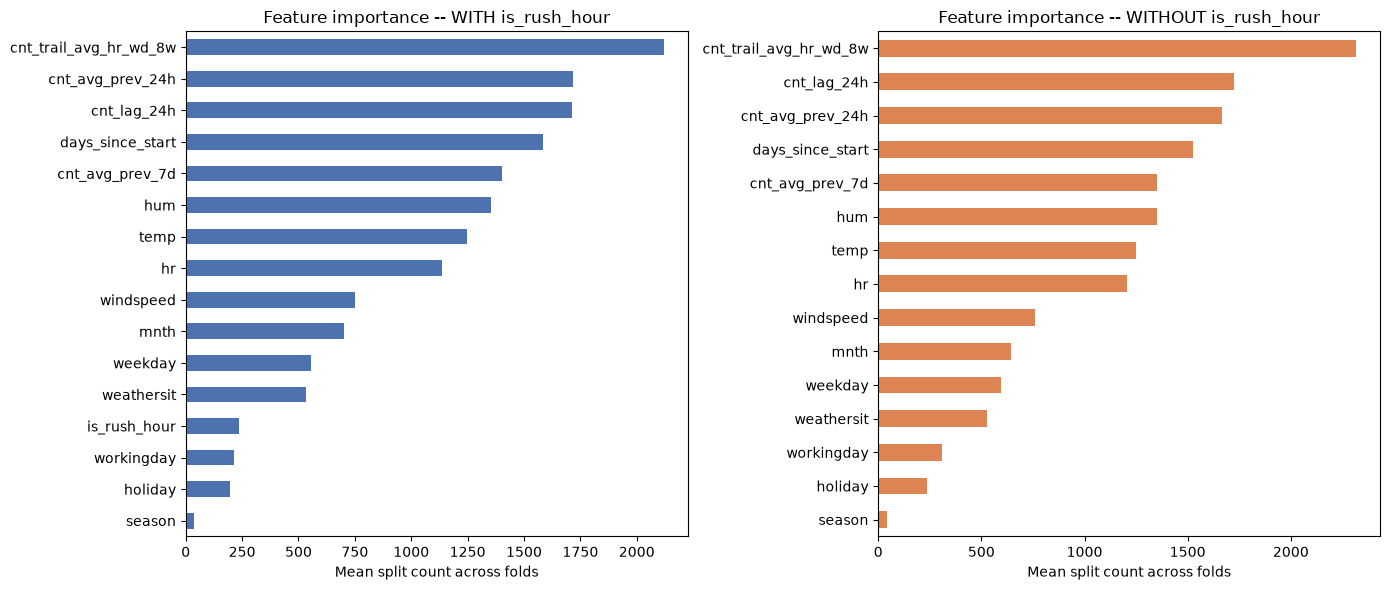

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=False)

importance_with_rush['mean'].sort_values().plot(
    kind='barh', ax=axes[0], color='#4C72B0'
)
axes[0].set_title('Feature importance -- WITH is_rush_hour')
axes[0].set_xlabel('Mean split count across folds')

importance_no_rush['mean'].sort_values().plot(
    kind='barh', ax=axes[1], color='#DD8452'
)
axes[1].set_title('Feature importance -- WITHOUT is_rush_hour')
axes[1].set_xlabel('Mean split count across folds')

plt.tight_layout()
plt.show()

## 7. Light GBM - Target= "registered+casual"

In [46]:
# Build lag/rolling features for casual and registered separately (same leakage-safe function
# used for cnt, just pointed at each target column).
df = build_lag_rolling_features(df, target_col='casual')
df = build_lag_rolling_features(df, target_col='registered')

def make_feature_cols(target_col):
    """Same weather/calendar/trend/rush-hour features as the cnt model, but with the
    lag/rolling block swapped to this target's own history."""
    return [
        'hr', 'weekday', 'mnth', 'season', 'holiday', 'workingday', 'weathersit',
        'temp', 'hum', 'windspeed',
        'days_since_start',
        f'{target_col}_lag_24h', f'{target_col}_avg_prev_24h',
        f'{target_col}_avg_prev_7d', f'{target_col}_trail_avg_hr_wd_8w',
        'is_rush_hour',
    ]

CASUAL_FEATURE_COLS = make_feature_cols('casual')
REGISTERED_FEATURE_COLS = make_feature_cols('registered')

# dropna needs to be joint: a row only qualifies if it has complete history for BOTH
# casual and registered (since we sum their predictions), not just one or the other.
combined_required_cols = list(set(CASUAL_FEATURE_COLS + REGISTERED_FEATURE_COLS))
df_model_split = df.dropna(subset=combined_required_cols).reset_index(drop=True)
print(f"df_model_split rows: {len(df_model_split)} (vs df_model for direct cnt: {len(df_model)})")

df_model_split rows: 17078 (vs df_model for direct cnt: 17078)


In [47]:
def run_walk_forward_split(data, run_name):
    """Trains separate LightGBM models for casual and registered, sums their predictions,
    and evaluates the sum against true cnt on the same folds/metrics as the direct model."""
    fold_metrics = []

    with mlflow.start_run(run_name=run_name):
        mlflow.log_params(LGB_PARAMS)
        mlflow.log_param("casual_feature_cols", CASUAL_FEATURE_COLS)
        mlflow.log_param("registered_feature_cols", REGISTERED_FEATURE_COLS)
        mlflow.log_param("n_folds", len(fold_boundaries))

        for fold_idx, (train_end, val_start, val_end) in enumerate(fold_boundaries):
            train_fold = data[data['timestamp'] < train_end]
            val_fold = data[(data['timestamp'] >= val_start) & (data['timestamp'] <= val_end)]

            model_casual = lgb.LGBMRegressor(**LGB_PARAMS)
            model_casual.fit(
                train_fold[CASUAL_FEATURE_COLS], train_fold['casual'],
                categorical_feature=CATEGORICAL_FEATURES,
            )
            model_registered = lgb.LGBMRegressor(**LGB_PARAMS)
            model_registered.fit(
                train_fold[REGISTERED_FEATURE_COLS], train_fold['registered'],
                categorical_feature=CATEGORICAL_FEATURES,
            )

            preds_casual = np.clip(model_casual.predict(val_fold[CASUAL_FEATURE_COLS]), 0, None)
            preds_registered = np.clip(model_registered.predict(val_fold[REGISTERED_FEATURE_COLS]), 0, None)
            preds_cnt = preds_casual + preds_registered

            y_val = val_fold['cnt'].values

            fold_mae = mean_absolute_error(y_val, preds_cnt)
            fold_rmse = np.sqrt(mean_squared_error(y_val, preds_cnt))
            fold_mape = mean_absolute_percentage_error(y_val, preds_cnt) * 100

            fold_metrics.append({"mae": fold_mae, "rmse": fold_rmse, "mape": fold_mape})

            mlflow.log_metrics({
                f"fold_{fold_idx}_mae": fold_mae,
                f"fold_{fold_idx}_rmse": fold_rmse,
                f"fold_{fold_idx}_mape": fold_mape,
            })

            print(f"Fold {fold_idx}: train={len(train_fold)} val={len(val_fold)} "
                  f"| MAE={fold_mae:.1f} RMSE={fold_rmse:.1f} MAPE={fold_mape:.1f}%")

        val_mae_mean = np.mean([m["mae"] for m in fold_metrics])
        val_mae_std = np.std([m["mae"] for m in fold_metrics])
        val_rmse_mean = np.mean([m["rmse"] for m in fold_metrics])
        val_rmse_std = np.std([m["rmse"] for m in fold_metrics])
        val_mape_mean = np.mean([m["mape"] for m in fold_metrics])
        val_mape_std = np.std([m["mape"] for m in fold_metrics])

        mlflow.log_metrics({
            "val_mae_mean": val_mae_mean, "val_mae_std": val_mae_std,
            "val_rmse_mean": val_rmse_mean, "val_rmse_std": val_rmse_std,
            "val_mape_mean": val_mape_mean, "val_mape_std": val_mape_std,
        })

        print(f"\nVal summary -- MAE: {val_mae_mean:.1f} (+/-{val_mae_std:.1f}) "
              f"| RMSE: {val_rmse_mean:.1f} (+/-{val_rmse_std:.1f}) "
              f"| MAPE: {val_mape_mean:.1f}% (+/-{val_mape_std:.1f}%)")

    return fold_metrics

fold_metrics_split = run_walk_forward_split(df_model_split, run_name="casual_registered_split")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000607 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1489
[LightGBM] [Info] Number of data points in the train set: 11266, number of used features: 16
[LightGBM] [Info] Start training from score 29.598615
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000155 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1494
[LightGBM] [Info] Number of data points in the train set: 11266, number of used features: 16
[LightGBM] [Info] Start training from score 127.460767
Fold 0: train=11266 val=1441 | MAE=43.1 RMSE=66.6 MAPE=31.5%
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000190 seconds.
You can set `force_r

In [48]:
for i, m in enumerate(fold_metrics_split):
    print(f"Fold {i}: MAE={m['mae']:.1f} RMSE={m['rmse']:.1f} MAPE={m['mape']:.1f}%")

Fold 0: MAE=43.1 RMSE=66.6 MAPE=31.5%
Fold 1: MAE=45.9 RMSE=69.6 MAPE=22.2%
Fold 2: MAE=37.3 RMSE=56.7 MAPE=24.3%


## 8. Hyperparameter Tuning

In [49]:
from itertools import product

PARAM_GRID = {
    'num_leaves': [15, 32, 63],
    'learning_rate': [0.03, 0.05, 0.1],
    'n_estimators': [300, 500, 800],
    'min_child_samples': [10, 20, 40],
}

def evaluate_params(data, target_col, feature_cols, categorical_features, params):
    """Runs the same walk-forward evaluation as before, for one param combination.
    Returns mean/std MAE/RMSE/MAPE across folds -- no printing, no MLflow child run
    logging noise, since this gets called many times."""
    fold_maes, fold_rmses, fold_mapes = [], [], []

    for train_end, val_start, val_end in fold_boundaries:
        train_fold = data[data['timestamp'] < train_end]
        val_fold = data[(data['timestamp'] >= val_start) & (data['timestamp'] <= val_end)]

        X_train, y_train = train_fold[feature_cols], train_fold[target_col]
        X_val, y_val = val_fold[feature_cols], val_fold[target_col]

        model = lgb.LGBMRegressor(random_state=42, verbose=-1, **params)
        model.fit(X_train, y_train, categorical_feature=categorical_features)

        preds = np.clip(model.predict(X_val), 0, None)
        fold_maes.append(mean_absolute_error(y_val, preds))
        fold_rmses.append(np.sqrt(mean_squared_error(y_val, preds)))
        fold_mapes.append(mean_absolute_percentage_error(y_val, preds) * 100)

    return {
        'mae_mean': np.mean(fold_maes), 'mae_std': np.std(fold_maes),
        'rmse_mean': np.mean(fold_rmses), 'rmse_std': np.std(fold_rmses),
        'mape_mean': np.mean(fold_mapes), 'mape_std': np.std(fold_mapes),
    }

results = []
param_names = list(PARAM_GRID.keys())
combos = list(product(*PARAM_GRID.values()))
print(f"Running {len(combos)} param combinations x 3 folds each...")

with mlflow.start_run(run_name="cnt_hyperparam_search"):
    for combo in combos:
        params = dict(zip(param_names, combo))
        metrics = evaluate_params(df_model, 'cnt', FEATURE_COLS, CATEGORICAL_FEATURES, params)

        with mlflow.start_run(run_name=f"trial_{'_'.join(str(v) for v in combo)}", nested=True):
            mlflow.log_params(params)
            mlflow.log_metrics(metrics)

        results.append({**params, **metrics})
        print(f"{params} -> MAE={metrics['mae_mean']:.1f} RMSE={metrics['rmse_mean']:.1f} MAPE={metrics['mape_mean']:.1f}%")

results_df = pd.DataFrame(results).sort_values('mae_mean')
print("\nTop 5 by mean val MAE:")
print(results_df.head(5)[['num_leaves', 'learning_rate', 'n_estimators', 'min_child_samples', 'mae_mean', 'rmse_mean', 'mape_mean']])

Running 81 param combinations x 3 folds each...
{'num_leaves': 15, 'learning_rate': 0.03, 'n_estimators': 300, 'min_child_samples': 10} -> MAE=41.3 RMSE=62.6 MAPE=28.5%
{'num_leaves': 15, 'learning_rate': 0.03, 'n_estimators': 300, 'min_child_samples': 20} -> MAE=41.1 RMSE=62.2 MAPE=29.1%
{'num_leaves': 15, 'learning_rate': 0.03, 'n_estimators': 300, 'min_child_samples': 40} -> MAE=40.6 RMSE=61.8 MAPE=28.0%
{'num_leaves': 15, 'learning_rate': 0.03, 'n_estimators': 500, 'min_child_samples': 10} -> MAE=43.3 RMSE=64.2 MAPE=30.1%
{'num_leaves': 15, 'learning_rate': 0.03, 'n_estimators': 500, 'min_child_samples': 20} -> MAE=42.2 RMSE=62.5 MAPE=30.6%
{'num_leaves': 15, 'learning_rate': 0.03, 'n_estimators': 500, 'min_child_samples': 40} -> MAE=40.7 RMSE=61.3 MAPE=28.3%
{'num_leaves': 15, 'learning_rate': 0.03, 'n_estimators': 800, 'min_child_samples': 10} -> MAE=45.1 RMSE=65.9 MAPE=31.4%
{'num_leaves': 15, 'learning_rate': 0.03, 'n_estimators': 800, 'min_child_samples': 20} -> MAE=43.1 RMSE=

In [50]:
print(results_df.head(5)[['num_leaves', 'learning_rate', 'n_estimators', 'min_child_samples',
                            'mae_mean', 'rmse_mean', 'mape_mean']].to_string(index=False))

 num_leaves  learning_rate  n_estimators  min_child_samples  mae_mean  rmse_mean  mape_mean
         32           0.05           300                 20 40.017400  61.380066  27.962050
         32           0.05           300                 40 40.145426  61.601534  26.914506
         32           0.05           500                 40 40.162840  61.514233  27.360241
         32           0.05           500                 20 40.201812  61.159983  29.770714
         32           0.05           800                 40 40.337786  61.672460  27.317593


In [51]:
FINAL_PARAMS = dict(
    num_leaves=32,
    learning_rate=0.05,
    n_estimators=300,
    min_child_samples=40,
    random_state=42,
    verbose=-1,
)

## 9. Final Model Testing

In [52]:
train_final = df_model[df_model['timestamp'] < TEST_START]
test_final = df_model[(df_model['timestamp'] >= TEST_START) & (df_model['timestamp'] <= TEST_END)]

print(f"Final train: {len(train_final)} rows ({train_final['timestamp'].min()} -> {train_final['timestamp'].max()})")
print(f"Test:        {len(test_final)} rows ({test_final['timestamp'].min()} -> {test_final['timestamp'].max()})")

Final train: 15622 rows (2011-01-08 00:00:00 -> 2012-10-31 23:00:00)
Test:        1433 rows (2012-11-01 00:00:00 -> 2012-12-31 00:00:00)


In [56]:
with mlflow.start_run(run_name="cnt_final_model_test_eval"):
    mlflow.log_params(FINAL_PARAMS)
    mlflow.log_param("feature_cols", FEATURE_COLS)
    mlflow.log_param("categorical_features", CATEGORICAL_FEATURES)
    mlflow.log_param("train_rows", len(train_final))
    mlflow.log_param("test_rows", len(test_final))

    final_model = lgb.LGBMRegressor(**FINAL_PARAMS)
    final_model.fit(
        train_final[FEATURE_COLS], train_final['cnt'],
        categorical_feature=CATEGORICAL_FEATURES,
    )

    test_preds = np.clip(final_model.predict(test_final[FEATURE_COLS]), 0, None)
    y_test = test_final['cnt'].values

    test_mae = mean_absolute_error(y_test, test_preds)
    test_rmse = np.sqrt(mean_squared_error(y_test, test_preds))
    test_mape = mean_absolute_percentage_error(y_test, test_preds) * 100

    # naive seasonal baseline, evaluated on the exact same test rows, for the final comparison
    # naive seasonal baseline, evaluated on the same test rows, filtered separately since
    # cnt_lag_168h isn't in FEATURE_COLS so df_model's dropna didn't guarantee it's non-null here
    naive_mask = test_final['cnt_lag_168h'].notna()
    y_test_naive = test_final.loc[naive_mask, 'cnt'].values
    naive_test_preds = test_final.loc[naive_mask, 'cnt_lag_168h'].values

    naive_test_mae = mean_absolute_error(y_test_naive, naive_test_preds)
    naive_test_rmse = np.sqrt(mean_squared_error(y_test_naive, naive_test_preds))
    naive_test_mape = mean_absolute_percentage_error(y_test_naive, naive_test_preds) * 100

    mlflow.log_metrics({
        "test_mae": test_mae, "test_rmse": test_rmse, "test_mape": test_mape,
        "naive_test_mae": naive_test_mae, "naive_test_rmse": naive_test_rmse, "naive_test_mape": naive_test_mape,
    })

    print(f"Final LightGBM model -- Test MAE={test_mae:.1f} RMSE={test_rmse:.1f} MAPE={test_mape:.1f}%")
    print(f"Naive seasonal        -- Test MAE={naive_test_mae:.1f} RMSE={naive_test_rmse:.1f} MAPE={naive_test_mape:.1f}%")

    mlflow.lightgbm.log_model(final_model, artifact_path="model")
    run_id_final = mlflow.active_run().info.run_id
    print(f"\nFinal run_id: {run_id_final}")

2026/09/13 20:05:01 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Final LightGBM model -- Test MAE=40.1 RMSE=69.2 MAPE=46.7%
Naive seasonal        -- Test MAE=72.4 RMSE=118.7 MAPE=103.3%

Final run_id: e7c0a6d36bcb44b89a3a596d6a3efbe3


## 10. Residual Analysis

In [57]:
test_final = test_final.copy()
test_final['residual'] = y_test - test_preds          # positive = model under-predicted
test_final['abs_residual'] = np.abs(test_final['residual'])

print(f"Mean residual: {test_final['residual'].mean():.2f}  (should be near 0 -- systematic bias check)")
print(f"Std of residual: {test_final['residual'].std():.2f}")

Mean residual: -10.68  (should be near 0 -- systematic bias check)
Std of residual: 68.39


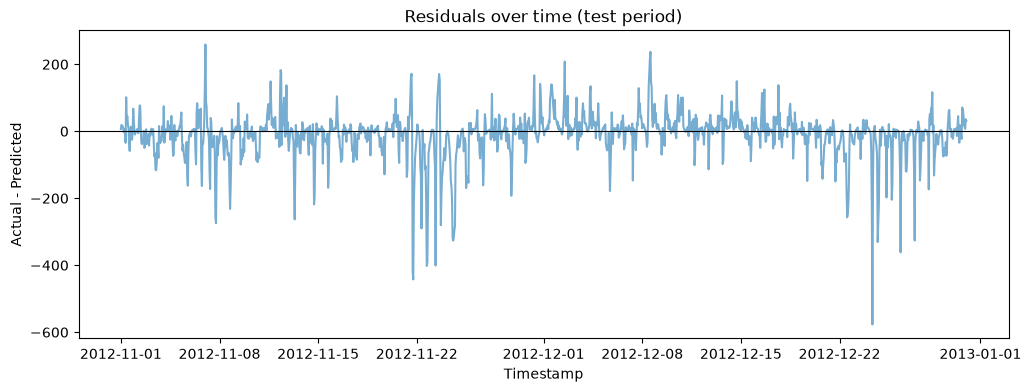

In [58]:
# 1. Residuals over time -- catches whether errors cluster in specific days/weeks
#    (e.g. the post-Sandy or holiday period) rather than being spread evenly.
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(test_final['timestamp'], test_final['residual'], alpha=0.6)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Residuals over time (test period)')
ax.set_xlabel('Timestamp')
ax.set_ylabel('Actual - Predicted')
plt.show()

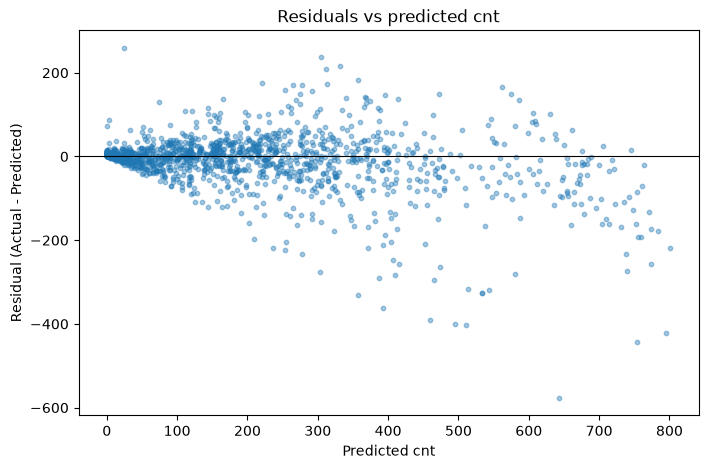

In [59]:
# 2. Residuals vs predicted value -- checks for heteroscedasticity: does error variance
#    grow with demand level? If the funnel widens to the right, the model is less reliable
#    at high-demand hours, which matters for capacity-planning use cases.
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(test_preds, test_final['residual'], alpha=0.4, s=10)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Residuals vs predicted cnt')
ax.set_xlabel('Predicted cnt')
ax.set_ylabel('Residual (Actual - Predicted)')
plt.show()

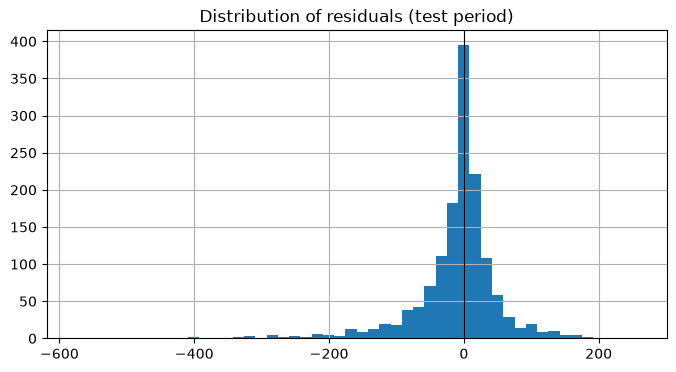

In [60]:
# 3. Residual distribution -- checks shape (should be roughly symmetric around 0, not
#    skewed) and flags fat tails / outlier hours.
fig, ax = plt.subplots(figsize=(8, 4))
test_final['residual'].hist(bins=50, ax=ax)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Distribution of residuals (test period)')
plt.show()

    mean_actual  mean_abs_residual  mean_residual
hr                                               
0     51.901639          20.527815      -3.527761
1     34.800000          13.630792       2.572421
2     21.000000           9.085630       2.251127
3     10.648148           6.062273       2.726582
4      7.379310           6.340814       5.809891
5     23.016667           6.579755       2.492388
6     77.366667          16.915400      -3.238088
7    224.533333          41.815845     -11.812024
8    409.483333          90.142199     -43.927103
9    242.783333          44.605188      -8.301315
10   179.883333          26.942217      -3.572307
11   218.100000          36.363734      -0.633765
12   274.483333          54.646292      -8.069945
13   279.983333          52.661580      -3.169591
14   265.416667          55.573152      -7.170331
15   282.500000          51.635771      -8.229139
16   336.833333          57.708395     -13.694726
17   437.916667         110.725338     -82.344764


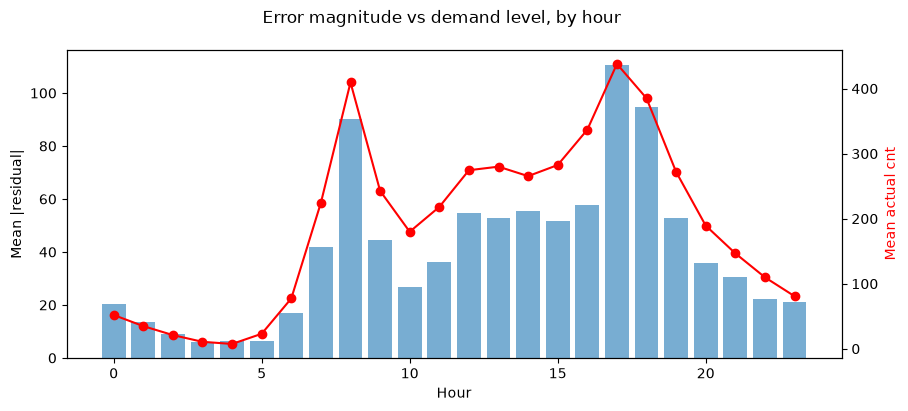

In [61]:
# 4. Residuals by hour -- directly tests the MAPE hypothesis from before: are the biggest
#    relative errors concentrated in specific low-demand hours (overnight)?
hourly_residual = test_final.groupby('hr').agg(
    mean_actual=('cnt', 'mean'),
    mean_abs_residual=('abs_residual', 'mean'),
    mean_residual=('residual', 'mean'),
)
print(hourly_residual)

fig, ax1 = plt.subplots(figsize=(10, 4))
ax1.bar(hourly_residual.index, hourly_residual['mean_abs_residual'], alpha=0.6, label='Mean |residual|')
ax1.set_xlabel('Hour')
ax1.set_ylabel('Mean |residual|')
ax2 = ax1.twinx()
ax2.plot(hourly_residual.index, hourly_residual['mean_actual'], color='red', marker='o', label='Mean actual cnt')
ax2.set_ylabel('Mean actual cnt', color='red')
fig.suptitle('Error magnitude vs demand level, by hour')
plt.show()

In [62]:
# 5. Residuals by weathersit and by workingday/holiday -- checks whether specific
#    conditions (bad weather, holidays) are where the model systematically struggles.
print(test_final.groupby('weathersit')['residual'].agg(['mean', 'std', 'count']))
print()
print(test_final.groupby('holiday')['residual'].agg(['mean', 'std', 'count']))
print()
print(test_final.groupby('workingday')['residual'].agg(['mean', 'std', 'count']))

                 mean        std  count
weathersit                             
1          -15.024197  71.621978    809
2           -2.673972  59.147384    527
3          -17.886466  82.840708     97

              mean         std  count
holiday                              
0        -9.286250   65.916552   1363
1       -37.736958  102.581804     70

                 mean        std  count
workingday                             
0          -11.355453  71.813122    502
1          -10.309676  66.508831    931
